In [1]:
#!/usr3/graduate/jtszhu/.conda/envs/TA2_jtz/bin/python3
# coding: utf-8

from pandas import read_csv
from pandas import DataFrame
from pandas import Grouper
from matplotlib import pyplot
import scipy

from scipy import stats
import json
import numpy as np
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import seaborn as sns

from scipy.stats import norm
from scipy.stats import ttest_rel
from scipy.stats import ttest_1samp
from scipy.stats import ttest_ind
import pingouin as pg
from tqdm import tqdm

from joblib import Parallel, delayed

import matplotlib as mpl

import random

import psutil

import os
os.environ["OMP_WAIT_POLICY"] = "active"

import graph_tool.all as gt
gt.openmp_enabled()

import scipy.sparse
import scipy.sparse.csgraph


dir_dict = {'sessionDir': [
    "R0817_20181120",
    "R0817_20190625",
    "R1187_20181119", "R1187_20190703",
    "R0959_20181128", "R0959_20190703",
    "R1373_20181128", "R1373_20190708",
    "R0983_20190722",
    "R0983_20190723",
    "R1507_20190621", "R1507_20190627",
    "R0898_20190723",
    "R0898_20190724",
    "R1452_20181119", "R1452_20190711",
    "R1547_20190729", "R1547_20190730",
    "R1103_20181121",
    "R1103_20190710"
],
    'bietfpDir': [
        "R0817_TA2_11.20.18",
        "R0817_TA2_6.25.19",
        "R1187_TA2_11.19.18", "R1187_TA2_7.3.19",
        "R0959_TA2_11.28.18", "R0959_TA2_7.3.19",
        "R1373_TA2_11.28.18", "R1373_TA2_7.8.19",
        "R0983_TA2_7.22.19",
        "R0983_TA2_7.23.19",
        "R1507_TA2_6.21.19", "R1507_TA2_6.27.19",
        "R0898_TA2_7.23.19",
        "R0898_TA2_7.24.19",
        "R1452_TA2_11.19.18", "R1452_TA2_7.11.19",
        "R1547_TA2_7.29.19", "R1547_TA2_7.30.19",
        "R1103_TA2_11.21.18",
        "R1103_TA2_7.10.19"

    ],
}
aparc_list_in_lobe_order = ['lateraloccipital', 'lingual', 'cuneus', 'pericalcarine',
                            'superiorparietal', 'inferiorparietal', 'supramarginal', 'postcentral', 'precuneus',
                    'isthmuscingulate', 'posteriorcingulate',
                                                'superiortemporal', 'middletemporal', 'inferiortemporal', 'bankssts', 'fusiform',
              'transversetemporal', 'entorhinal', 'temporalpole', 'parahippocampal',
              'superiorfrontal', 'rostralmiddlefrontal', 'caudalmiddlefrontal', 'parstriangularis',
                    'parsopercularis', 'parsorbitalis', 'lateralorbitofrontal', 'medialorbitofrontal',
              'precentral', 'paracentral', 'frontalpole','rostralanteriorcingulate', 'caudalanteriorcingulate',

                            'insula'
              ]

aparc_hh_list = list()
for roi_str in aparc_list_in_lobe_order:
    aparc_hh_list.append(roi_str + '_lh')
    aparc_hh_list.append(roi_str + '_rh')

occipital_rois = ['lateraloccipital', 'lingual', 'cuneus', 'pericalcarine']
parietal_rois = ['superiorparietal', 'inferiorparietal', 'supramarginal', 'postcentral', 'precuneus']
temporal_rois = ['superiortemporal', 'middletemporal', 'inferiortemporal', 'bankssts', 'fusiform',
              'transversetemporal', 'entorhinal', 'temporalpole', 'parahippocampal']
frontal_rois = [ 'superiorfrontal', 'rostralmiddlefrontal', 'caudalmiddlefrontal', 'parstriangularis',
                    'parsopercularis', 'parsorbitalis', 'lateralorbitofrontal', 'medialorbitofrontal',
              'precentral', 'paracentral', 'frontalpole']
cingulate_rois = ['isthmuscingulate', 'posteriorcingulate','rostralanteriorcingulate', 'caudalanteriorcingulate']
insula_roi = ['insula']

frontal_precentral =  ['precentral', 'paracentral']
frontal_rostralmiddle = ['superiorfrontal', 'rostralmiddlefrontal', 'caudalmiddlefrontal', 'parstriangularis','parsopercularis']
frontal_lateralorbito = ['parsorbitalis', 'lateralorbitofrontal', 'medialorbitofrontal', 'frontalpole']


def get_lobe_idxs(rois, hemi='lh'):
    rois_idxs = list()
    for item in rois:
        print(item)
        rois_idxs.append(int(np.where(np.array(aparc_hh_list) == item+'_'+hemi)[0]))
    print(rois_idxs)
    return rois_idxs


occipital_left_idxs = get_lobe_idxs(occipital_rois, hemi='lh')
occipital_right_idxs = get_lobe_idxs(occipital_rois, hemi='rh')
temporal_left_idxs = get_lobe_idxs(temporal_rois, hemi='lh')
temporal_right_idxs = get_lobe_idxs(temporal_rois, hemi='rh')
parietal_left_idxs = get_lobe_idxs(parietal_rois, hemi='lh')
parietal_right_idxs = get_lobe_idxs(parietal_rois, hemi='rh')
frontal_left_idxs = get_lobe_idxs(frontal_rois, hemi='lh')
frontal_right_idxs = get_lobe_idxs(frontal_rois, hemi='rh')
cingulate_left_idxs = get_lobe_idxs(cingulate_rois, hemi='lh')
cingulate_right_idxs = get_lobe_idxs(cingulate_rois, hemi='rh')
insula_left_idxs = get_lobe_idxs(insula_roi, hemi='lh')
insula_right_idxs = get_lobe_idxs(insula_roi, hemi='rh')
frontal_precentral_lh_idxs = get_lobe_idxs(frontal_precentral, hemi='lh')
frontal_rostralmiddle_lh_idxs = get_lobe_idxs(frontal_rostralmiddle, hemi='lh')
frontal_lateralorbito_lh_idxs = get_lobe_idxs(frontal_lateralorbito, hemi='lh')
frontal_precentral_rh_idxs = get_lobe_idxs(frontal_precentral, hemi='rh')
frontal_rostralmiddle_rh_idxs = get_lobe_idxs(frontal_rostralmiddle, hemi='rh')
frontal_lateralorbito_rh_idxs = get_lobe_idxs(frontal_lateralorbito, hemi='rh')

code_path = '/usr3/graduate/jtszhu/TA2/Decoding/'
import sys

this_folder = '/usr3/graduate/jtszhu/TA2'
sys.path.append(this_folder)

import Decoding.PlotAllStats as pas

stype = 's1'

from LoadData_TANoise import Data as DataNoise
from LoadData import Data as Data

import PlotFigures as pf
import Settings as pltSet

data_exp = 'TA2'
sessionDir_list = dir_dict['sessionDir']
sessionDir = dir_dict['sessionDir'][0]
bietfpDir = dir_dict['bietfpDir'][0]

data = None
if data_exp == 'noise':
    data = DataNoise(sessionDir, bietfpDir, load_meg=False)
else:
    data = Data(sessionDir, bietfpDir, load_meg=False)

time_ahead = data.time_ahead

pstart = -500
avg_timestep = 5


# get decoding results from data path
def get_res(dir_dict, para_set, stype, data_path, code_path, precue='T1'):
    if precue == 'T1':
        not_precue = 'T2'
    elif precue == 'T2':
        not_precue = 'T1'
    os.chdir(data_path)
    print('data_path', data_path)

    json_file_path = os.path.join(code_path, 'sourcedecoding_env.json')
    with open(json_file_path, 'r') as j:
        para_j = json.loads(j.read())

    if para_set[:12] == 'TA2_aparcr10':
        para_dict = para_j['TA2_aparcr10']
        dtype = para_set[13:]
    if para_set[:13] == 'TA2_aparcr100':
        para_dict = para_j['TA2_aparcr100']
        dtype = para_set[14:]
    elif para_set[:15] == 'TA2_aparctopr10':
        para_dict = para_j['TA2_aparctopr10']
        dtype = para_set[16:] + '_top33'
    else:
        para_dict = para_j[para_set]
        dtype = para_dict['dtype']

    print('dtype:', dtype)

    data_exp = para_dict['data_exp']
    avg_timestep = para_dict['avg_timestep']
    fold_k = para_dict['fold_k']
    nReps = para_dict['nReps']
    avg_trial = para_dict['avg_trial']
    topN = para_dict['topN']

    decode_by_sensors = para_dict['decode_by_sensors']
    ico_size = para_dict['ico_size']
    label = para_dict['label']

    sessionDir_list = dir_dict['sessionDir']
    sessionDir = dir_dict['sessionDir'][0]
    bietfpDir = dir_dict['bietfpDir'][0]

    para_str = "avg%sf%st%sCh%snReps%s%s%s.npy" % (avg_timestep, fold_k,
                                                   avg_trial, topN, nReps, dtype, stype)
    plot_para_str = "avg %s, %s fold, avg %s trials, Ch %s, %s rep, %s, session %s " % \
                    (avg_timestep, fold_k, avg_trial, topN, nReps, dtype, stype)

    this_score_list_arr_this_precue = pf.load_score_arr(
        "score_list_precue%s_%s_" % (precue, precue) + para_str[:-4], sessionDir_list, is_avg=False)
    this_score_list_arr_not_this_precue = pf.load_score_arr(
        "score_list_precue%s_%s_" % (not_precue, precue) + para_str[:-4], sessionDir_list, is_avg=False)

    this_score_list_arr_this_precue = np.mean(np.mean(this_score_list_arr_this_precue, axis=3), axis=1)
    this_score_list_arr_not_this_precue = np.mean(np.mean(this_score_list_arr_not_this_precue, axis=3), axis=1)

    return this_score_list_arr_this_precue, this_score_list_arr_not_this_precue


####################
# Load T1 decoding data
#####################
at_list = list()
uat_list = list()
for region in aparc_hh_list:
    print('region:', region)
    fig_path = os.path.join('/projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/68regions_r100/', region,
                            'figures')
    dir = os.listdir(fig_path)

    para_set = 'TA2_aparcr100_' + region
    data_path = '/projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/68regions_r100/%s/res' % region

    attend_acc, unattend_acc = get_res(dir_dict, para_set, stype, data_path, code_path)
    at_list.append(attend_acc)
    uat_list.append(unattend_acc)
T1at_arr = np.array(at_list)
T1uat_arr = np.array(uat_list)

####################
# Load T2 decoding data
#####################

at_list = list()
uat_list = list()
for region in aparc_hh_list:
    print('region:', region)
    fig_path = os.path.join('/projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/68regions_r100/', region,
                            'figures')
    dir = os.listdir(fig_path)

    para_set = 'TA2_aparcr100_' + region
    data_path = '/projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/68regions_r100/%s/res' % region

    attend_acc, unattend_acc = get_res(dir_dict, para_set, stype, data_path, code_path, precue='T2')
    at_list.append(attend_acc)
    uat_list.append(unattend_acc)
T2at_arr = np.array(at_list)
T2uat_arr = np.array(uat_list)


lobe_name_list = ['occipital_lh', 'occipital_rh', 'parietal_lh', 'parietal_rh',
                  'temporal_lh', 'temporal_rh', 'frontal_lh', 'frontal_rh',
                  'cingulate_lh', 'cingulate_rh', 'insula_lh', 'insula_rh'
                  ]

x_array = np.array(
    range(data.time_window_T1_tmp[0] + pstart, data.time_window_af_cueT_tmp[0] + pstart - avg_timestep - 10 * 5,
          avg_timestep))

lobe_idxs_list = [occipital_left_idxs, occipital_right_idxs, parietal_left_idxs, parietal_right_idxs,
                  temporal_left_idxs, temporal_right_idxs, frontal_left_idxs, frontal_right_idxs,
                  cingulate_left_idxs, cingulate_right_idxs, insula_left_idxs, insula_right_idxs
                  ]

def avg_sessions_for_subjects(y1, y2):
    new_y1 = []
    new_y2 = []
    for i in range(0, len(y1),2):
        new_y1.append((y1[i]+y1[i+1])/2)
        new_y2.append((y2[i]+y2[i+1])/2)
    return np.array(new_y1), np.array(new_y2)


def get_net_centrality_func(t, input_arr, aparc_list, operation='mean', stride=5, ed_t=59, st_t=10, win=10, resolt=1):
    # for t in range(st_t, ed_t, stride):
    # print('time', int(t*5/resolt)-50, 'ms')
    input_m = np.mean(input_arr[:, :, t:t + win], axis=1)
    # print(at_m)
    corr_at_dis_matrix = 1 - np.abs(np.corrcoef(input_m))

    # Number of variables
    num_variables = corr_at_dis_matrix.shape[0]

    # Create an empty graph
    g = gt.Graph(directed=False)
    eweight = g.new_ep("double")

    # Add vertices (nodes)
    g.add_vertex(num_variables)

    # Add edges with weights (correlations)
    for i in range(num_variables):
        for j in range(i, num_variables):
            weight = corr_at_dis_matrix[i, j]
            e = g.add_edge(i, j)
            eweight[e] = weight

    with gt.openmp_context(nthreads=68, schedule="guided"):
        closeness_centrality = gt.closeness(g, weight=eweight)

    rois_centrality = list(closeness_centrality.get_array())  # 'weight'

    if operation == 'mean':
        this_avg_op = np.mean(input_arr[:, :, t:t + win], axis=2)
    elif operation == 'max':
        this_avg_op = np.max(input_arr[:, :, t:t + win], axis=2)
    elif operation == 'time':
        this_avg_op = input_arr[:, :, t]
    rois_avg_acc = (np.mean(this_avg_op, axis=1))  # avearge sessions

    del g

    return rois_centrality, rois_avg_acc


def get_centrality_list(input_arr, aparc_list, operation='mean', stride=5, ed_t=59, st_t=10, win=10, resolt=1):
    rois_avg_acc_list = list()
    rois_centrality_list = list()
    # print('hi')
    #     res = Parallel(n_jobs=10)(delayed(get_net_centrality_func)(t,input_arr,aparc_list, operation,stride, ed_t,st_t, win,resolt) for t in range(st_t, ed_t, stride))
    #     # res = get_net_centrality_func(0,input_arr,aparc_list, operation,stride, ed_t,st_t, win,resolt)
    #     for item in res:
    #         rois_centrality_list.append(item[0])
    #         rois_avg_acc_list.append(item[1])

    for t in range(st_t, ed_t, stride):
        res = get_net_centrality_func(t, input_arr, aparc_list, operation, stride, ed_t, st_t, win, resolt)

        rois_centrality_list.append(res[0])
        rois_avg_acc_list.append(res[1])  # avearge sessions
    return rois_centrality_list, rois_avg_acc_list


def get_group_property(y1_arr, y2_arr, net_type='corrsum', is_by_rois=False,
                       rois_idxs=None):  # correlation sum /  closeness centrality
    # input shape: sess * time * rois
    # return variable size: # rois * time step
    # functional connectivity (correlation matrix) based on decoding accuracy
    stride = 1
    y1_arr = y1_arr.transpose(2, 0, 1)  # rois * sess * time
    y2_arr = y2_arr.transpose(2, 0, 1)

    y1_group_corr_list = get_group_corr_list(np.sum(y1_arr, axis=1), aparc_hh_list, stride=stride, st_t=0,
                                             ed_t=259 - 10)
    y2_group_corr_list = get_group_corr_list(np.sum(y2_arr, axis=1), aparc_hh_list, stride=stride, st_t=0,
                                             ed_t=259 - 10)

    if net_type == 'corrsum':
        y1_group_prop, y2_group_prop = get_corrsum(y1_group_corr_list, y2_group_corr_list)
        if is_by_rois:
            y1_group_prop, y2_group_prop = y1_group_prop[rois_idxs, :], y2_group_prop[rois_idxs, :]

    elif net_type == 'closeness':
        y1_group_closeness_list, _ = get_centrality_list(y1_arr, aparc_hh_list, stride=stride, st_t=0, ed_t=259 - 10)
        y2_group_closeness_list, _ = get_centrality_list(y2_arr, aparc_hh_list, stride=stride, st_t=0, ed_t=259 - 10)

        y1_group_prop = np.array(y1_group_closeness_list).transpose()
        y2_group_prop = np.array(y2_group_closeness_list).transpose()

        if is_by_rois:
            y1_group_prop, y2_group_prop = y1_group_prop[rois_idxs, :], y2_group_prop[rois_idxs, :]

        del y1_group_closeness_list, y2_group_closeness_list
    # print(np.shape(y1_group_prop))

    return y1_group_prop, y2_group_prop



def get_group_corr_list(input_arr, aparc_list, stride=5, ed_t=59, st_t=10):
    # print('getting corr values:')
    this_group_corr = list()
    for t in range(st_t, ed_t, stride):
        sess_input = input_arr[:, t:t+10]
        # get correlation_matrix by each session
        corr_dis_matrix = np.abs(np.corrcoef(sess_input))
        this_group_corr.append(corr_dis_matrix)

    return this_group_corr



def plot_error_by_axs(x_array, score_arr, plot_title, this_label, subplot_axs):

    y = np.mean(score_arr, axis=0)
    subplot_axs.plot(x_array, y)
    if this_label == 'STD':
        error = np.std(score_arr, axis=0)
        subplot_axs.fill_between(x_array, y-error, y+error, alpha=0.5, label='STD')
    else:
        error = stats.sem(score_arr, axis=0)
        subplot_axs.fill_between(x_array, y-error, y+error, alpha=0.5, label=plot_title)




/usr3/graduate/jtszhu/.conda/envs/TA2_jtz/lib/python3.8/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package outdated is out of date. Your version is 0.2.1, the latest is 0.2.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
/usr3/graduate/jtszhu/.conda/envs/TA2_jtz/lib/python3.8/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.0, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
/usr3/graduate/jtszhu/.conda/envs/TA2_jtz/lib/python3.8/site-packages/graph_tool/draw/cairo_draw.py:1557: RuntimeWarning: Error importing Gtk module: Typelib file for namespace 'GObject', version '2.0' not found; GTK+ drawing will not work.
  warnings.warn(msg, RuntimeWarning)


lateraloccipital
lingual
cuneus
pericalcarine
[0, 2, 4, 6]
lateraloccipital
lingual
cuneus
pericalcarine
[1, 3, 5, 7]
superiortemporal
middletemporal
inferiortemporal
bankssts
fusiform
transversetemporal
entorhinal
temporalpole
parahippocampal
[22, 24, 26, 28, 30, 32, 34, 36, 38]
superiortemporal
middletemporal
inferiortemporal
bankssts
fusiform
transversetemporal
entorhinal
temporalpole
parahippocampal
[23, 25, 27, 29, 31, 33, 35, 37, 39]
superiorparietal
inferiorparietal
supramarginal
postcentral
precuneus
[8, 10, 12, 14, 16]
superiorparietal
inferiorparietal
supramarginal
postcentral
precuneus
[9, 11, 13, 15, 17]
superiorfrontal
rostralmiddlefrontal
caudalmiddlefrontal
parstriangularis
parsopercularis
parsorbitalis
lateralorbitofrontal
medialorbitofrontal
precentral
paracentral
frontalpole
[40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60]
superiorfrontal
rostralmiddlefrontal
caudalmiddlefrontal
parstriangularis
parsopercularis
parsorbitalis
lateralorbitofrontal
medialorbitofrontal
precen

 25%|██▌       | 5/20 [00:00<00:00, 43.29it/s]

region: lateraloccipital_lh
data_path /projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/68regions_r100/lateraloccipital_lh/res
dtype: lateraloccipital_lh


 25%|██▌       | 5/20 [00:00<00:00, 46.75it/s]

...

 25%|██▌       | 5/20 [00:00<00:00, 45.13it/s]

region: insula_lh
data_path /projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/68regions_r100/insula_lh/res
dtype: insula_lh


 25%|██▌       | 5/20 [00:00<00:00, 42.52it/s]

region: insula_rh
data_path /projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/68regions_r100/insula_rh/res
dtype: insula_rh


100%|██████████| 20/20 [00:00<00:00, 43.66it/s]


In [12]:
def get_lagged_r2_spatiotemp_full(x1,x2, win=10):
    lagcorr = np.zeros((len(x1),len(x2)))
    for i in range(0,len(x1)-win):
        for j in range(0,len(x2)-win):
            xarr=x1[i:i+win]
            yarr=x2[j:j+win]
            # print(np.corrcoef(xarr, yarr))
            
            lagcorr[i,j] = np.square(np.corrcoef(xarr, yarr)[0,1])

    return lagcorr 

In [2]:
def plot_cross_corr(inputx1,inputx2,lobe1_str,lobe2_str,is_r2=True, r2_thres=0.55, is_plot=True):
    if is_r2:
        lagcor = get_lagged_r2_spatiotemp_full(np.mean(inputx2,axis=0),np.mean(inputx1,axis=0))
    else:
        lagcor = get_lagged_corr_spatiotemp_full(np.mean(inputx2,axis=0),np.mean(inputx1,axis=0))
    
    # Generate a mask for the lower triangle
    mask = np.tril(np.ones_like(lagcor, dtype=bool))

    # Generate a mask for the upper triangle
    mask = np.tril(np.ones_like(lagcor, dtype=bool))



    if is_r2:
        idxs = np.where(np.abs(lagcor)<r2_thres)
    else:
        idxs = np.where(np.abs(lagcor)<0.7)
        
    masked_lagcor = lagcor.copy()
    masked_lagcor[idxs] = 0

    df_masked_lagcor = pd.DataFrame(masked_lagcor)
    df_masked_lagcor.columns = x_array - 1050
    df_masked_lagcor.index = x_array - 1050
    
    if is_plot:
        # Set up the matplotlib figure
        f, ax = plt.subplots(figsize=(15, 5))

        # Draw the heatmap with the mask and correct aspect ratio
        if is_r2:
            cmap = sns.color_palette("rocket", as_cmap=True)
            sns.heatmap(df_masked_lagcor, cmap=cmap, vmin=0, vmax=1, center=0.5,
                square=True)
        else:
            # Generate a custom diverging colormap
            cmap = sns.diverging_palette(230, 20, as_cmap=True)
            sns.heatmap(df_masked_lagcor, cmap=cmap, vmin=-1, vmax=1, center=0,
                        square=True, cbar_kws={"shrink": .5})


    #     ax.contour(df_masked_lagcor, colors='red', linewidth=0.5)


        time_ahead = 50

        ax.axvline(x= int((data.time_window_T1_tmp[0] + data.pstart + time_ahead -1000)/5), color='grey', linewidth=1,  ls='--')


        ax.axvline(x= int((data.time_window_T2_tmp[0] + data.pstart + time_ahead -1000)/5), color='grey', linewidth=1, ls='--')

        ax.axvline(x= int((data.time_window_af_cueT_tmp[0] + data.pstart-1000)/5), color='grey', linewidth=1, ls='--')

        ax.axhline(y= int((data.time_window_T1_tmp[0] + data.pstart + time_ahead -1000)/5), color='grey', linewidth=1,  ls='--')

        ax.axhline(y= int((data.time_window_T2_tmp[0] + data.pstart + time_ahead -1000)/5), color='grey', linewidth=1, ls='--')

        ax.axhline(y= int((data.time_window_af_cueT_tmp[0] + data.pstart-1000)/5), color='grey', linewidth=1, ls='--')



        ax.set_xticks(np.array([0, 150,300, 450, 600,750,900,1050,1200])/5 + 10)
        ax.set_yticks(np.array([0, 150,300, 450, 600,750,900,1050,1200])/5 + 10)

        ax.set_xticklabels(np.array([0, 150,300, 450, 600,750,900,1050,1200]))
        ax.set_yticklabels(np.array([0, 150,300, 450, 600,750,900,1050,1200]))

        ax.plot([x_array[0] - 1050, x_array[-1] - 1050], [x_array[0] - 1050, x_array[-1] - 1050], ls="--", c=".3", linewidth=1)

        plt.ylabel(lobe1_str) # x-axis label with fontsize 15
        plt.xlabel(lobe2_str)
    return masked_lagcor
    
def get_win_avg_abscor(masked_lagcor,win=(69,99)):
    abs_agcor = np.abs(masked_lagcor)
    sum_vertical = np.sum(abs_agcor[win[0]:win[1],:],axis=0)
    
    return sum_vertical 

def smooth_coupling(sum_vertical,avg_len=30,is_plot=True):
    avg_coupling = pd.DataFrame(sum_vertical,columns =['value'])
    moving_avg = avg_coupling ['value'].rolling(window=5).mean()
    if is_plot:
        fig, ax = plt.subplots()
        plt.plot(x_array,moving_avg/avg_len)

        plt.axvline(x=data.time_window_T1_tmp[0] + data.pstart + time_ahead, color='grey', linewidth=1,  ls='--')
        #     axs.text(x=data.time_window_T1_tmp[0] + data.pstart + time_ahead-100+70, y=0.66, color='black', 
        #              fontsize=12*legend_size, s='T1')

        plt.axvline(x=data.time_window_T2_tmp[0] + data.pstart + time_ahead, color='grey', linewidth=1, ls='--')
        #     axs.text(x=data.time_window_T2_tmp[0] + data.pstart + time_ahead-100+70, y=0.66, color='black', 
        #              fontsize=12*legend_size, s='T2')

        plt.axvline(x=data.time_window_af_cueT_tmp[0] + data.pstart, color='grey', linewidth=1, ls='--')
        #     axs.text(x=data.time_window_af_cueT_tmp[0] + data.pstart-250, y=0.66, color='black', 
        #              fontsize=12*legend_size, s='Response cue')

        plt.xlim(1000, )
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x-1050))))
        plt.xticks(np.array([0, 150,300, 450, 600,750,900,1050,1200])+1050)
        plt.show()
    return moving_avg

def fft_coupling(input_data,win=(4+9,-60),avg_len=30):
    X = fft(np.array(input_data[win[0]:win[1]])/avg_len) # rolling window 5, first 4 data point are NaN 
    n_samples  = len(X)
    total_time = (x_array[win[1]]-x_array[win[0]])/1000 # Example total time range in seconds
    fs = n_samples / total_time

    # Generate the frequency axis
    freqs = np.fft.fftfreq(n_samples, 1/fs)

    # Get the positive frequencies (first half)
    positive_freqs = freqs[:n_samples // 2]
    positive_magnitudes = np.abs(X)[:n_samples // 2]
    positive_magnitudes[0]=0
    plt.plot(positive_freqs, positive_magnitudes)
    print(np.argmax(positive_magnitudes))
    print(np.argsort(positive_magnitudes)[::-1])
    plt.title("Magnitude Spectrum (Positive Frequencies)",fontsize=14)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.xlim(1,100)
    plt.ylim(0,np.max(positive_magnitudes)*1.1)
    plt.show()
    return positive_freqs, positive_magnitudes

In [118]:

def plot_one_fft(coupling_data,label_str, win=(4+9,-60), is_mark=False, ax=None, avg_len=30):    
    X = fft(np.array(coupling_data[win[0]:win[1]])/avg_len) # rolling window 5, first 4 data point are NaN 
    n_samples  = len(X)
    total_time = (x_array[win[1]]-x_array[win[0]])/1000 # Example total time range in seconds
    fs = n_samples / total_time

    # Generate the frequency axis
    freqs = np.fft.fftfreq(n_samples, 1/fs)

    ax.spines[['right', 'top']].set_visible(False)
    # Get the positive frequencies (first half)
    positive_freqs = freqs[:n_samples // 2]
    positive_magnitudes = np.abs(X)[:n_samples // 2]
    positive_magnitudes[0]=0
    plt.plot(positive_freqs, positive_magnitudes,label=label_str, linewidth=1.2)
    max_m = np.argmax(positive_magnitudes)
    if is_mark:
        ax.axvline(x=positive_freqs[max_m], color='coral', linewidth=1, ls='--')

    
    print(np.argmax(positive_magnitudes))
    print(np.argsort(positive_magnitudes)[::-1])
    sorted_freq = np.argsort(positive_magnitudes)[::-1]
    
    if is_mark:
        lim = ax.get_xlim()
        ax.set_xticks([])
        print(positive_freqs[max_m])
        
        this_fft = positive_magnitudes[1:51]
        this_pos_freqs =  positive_freqs[1:51]
        
        peaks = find_peaks(this_fft)[0]
        print(peaks)

        #print(peaks)
        # Sort peaks by amplitude (highest first)
        sorted_indices = np.argsort(this_fft[peaks])[::-1]
        peak_freqs =  this_pos_freqs[peaks][sorted_indices]
        
        # Get current ticks and add the new tick
        ticks = list(ax.get_xticks()) + [positive_freqs[max_m]]

        # Format the labels as you want (e.g., one decimal place)
        labels = [f"{x:.1f}" for x in ticks]

        # Set the new ticks and formatted labels
        ax.set_xticks(ticks)
        ax.set_xticklabels(labels, fontsize=XTICK_FONT_SIZE)
        
        ax.set_xticks(list(ax.get_xticks()) + [positive_freqs[max_m]])
        # ax.set_xticks(list(ax.get_xticks()) + [positive_freqs[sorted_freq[1]]])
#         ax.set_xticks(list(ax.get_xticks()) + [positive_freqs[sorted_freq[2]]])
#         ax.set_xticks(list(ax.get_xticks()) + [positive_freqs[sorted_freq[3]]])
        ax.set_xticks(list(ax.get_xticks()) + [peak_freqs[1]])
        ax.set_xticks(list(ax.get_xticks()) + [peak_freqs[2]])
        ax.set_xticks(list(ax.get_xticks()) + [positive_freqs[20]])
        ax.set_xticks(list(ax.get_xticks()) + [positive_freqs[40]])

In [3]:

def get_one_fft(coupling_data, win=(4+9,-60),avg_len=30,roundfreq=True):
    X = fft(np.array(coupling_data[win[0]:win[1]])/avg_len) # rolling window 5, first 4 data point are NaN 
    n_samples  = len(X)
    total_time = (x_array[win[1]]-x_array[win[0]])/1000 # Example total time range in seconds
    fs = n_samples / total_time

    # Generate the frequency axis
    freqs = np.fft.fftfreq(n_samples, 1/fs)


    # Get the positive frequencies (first half)
    positive_freqs = freqs[:n_samples // 2]
    positive_magnitudes = np.abs(X)[:n_samples // 2]
    positive_magnitudes[0]=0
    
    # Convert frequencies to integers
    if roundfreq:
        fixed_frequencies = np.round(positive_freqs).astype(int)
    else:
        fixed_frequencies = positive_freqs
    
#     max_m = np.argmax(fixed_frequencies)

    return fixed_frequencies, positive_magnitudes # ,fixed_frequencies[max_m]

In [4]:
def get_target_fft(arr1,arr2,lobe1_idxs,lobe2_idxs,lobe1_str,lobe2_str,r2_thres=0.55, win=np.array([9,39]),win_T2=60,roundfreq=True):
    # for T1, win_T2=0
#     arr1 = T2at_arr.copy()
#     arr2 = T2uat_arr.copy()

    lobe1 = np.mean(arr1[lobe1_idxs,:,:],axis=0)
    lobe2 = np.mean(arr1[lobe2_idxs,:,:],axis=0)

    inputx1 = lobe1 
    inputx2 = lobe2 

    masked_lagcor = plot_cross_corr(inputx1,inputx2,lobe1_str,lobe2_str,is_plot=False)

    sum_vertical = get_win_avg_abscor(masked_lagcor,win=win+win_T2)
    coupling_data1 = smooth_coupling(sum_vertical,is_plot=False)
    
    smoothing_shift = 0
    win_ed=-1
    if win_T2 == 0:
        smoothing_shift = 4
        win_ed=-60
        
    positive_freqs1, positive_magnitudes1 = get_one_fft(coupling_data1,win=(9+smoothing_shift+win_T2,win_ed),roundfreq=roundfreq)

   
    
    lobe1 = np.mean(arr2[lobe1_idxs,:,:],axis=0)
    lobe2 = np.mean(arr2[lobe2_idxs,:,:],axis=0)

    inputx1 = lobe1 
    inputx2 = lobe2 
    masked_lagcor = plot_cross_corr(inputx1,inputx2,lobe1_str,lobe2_str,is_plot=False)

    sum_vertical = get_win_avg_abscor(masked_lagcor,win=win+win_T2)
    coupling_data2 = smooth_coupling(sum_vertical,is_plot=False)
    positive_freqs2, positive_magnitudes2 = get_one_fft(coupling_data2,win=(9+smoothing_shift+win_T2,win_ed),roundfreq=roundfreq)
    
#     print(positive_freqs1)
#     print(positive_freqs2)
    
    return positive_freqs1, positive_magnitudes1, positive_freqs2, positive_magnitudes2


    


In [8]:
def get_target_fft_data(arr1,arr2,lobe1_idxs,lobe2_idxs,lobe1_str,lobe2_str,r2_thres=0.55, win=np.array([9,39]),win_T2=60):
    # for T1, win_T2=0
#     arr1 = T2at_arr.copy()
#     arr2 = T2uat_arr.copy()

    lobe1 = np.mean(arr1[lobe1_idxs,:,:],axis=0)
    lobe2 = np.mean(arr1[lobe2_idxs,:,:],axis=0)

    inputx1 = lobe1 
    inputx2 = lobe2 

    masked_lagcor = plot_cross_corr(inputx1,inputx2,lobe1_str,lobe2_str,is_plot=False)

    sum_vertical = get_win_avg_abscor(masked_lagcor,win=win+win_T2)
    coupling_data1 = smooth_coupling(sum_vertical,is_plot=False)
    
    smoothing_shift = 0
    win_ed=-1
    if win_T2 == 0:
        smoothing_shift = 4
        win_ed=-60
        
    positive_freqs1, positive_magnitudes1 = get_one_fft(coupling_data1,win=(9+smoothing_shift+win_T2,win_ed))

   
    
    lobe1 = np.mean(arr2[lobe1_idxs,:,:],axis=0)
    lobe2 = np.mean(arr2[lobe2_idxs,:,:],axis=0)

    inputx1 = lobe1 
    inputx2 = lobe2 
    masked_lagcor = plot_cross_corr(inputx1,inputx2,lobe1_str,lobe2_str,is_plot=False)

    sum_vertical = get_win_avg_abscor(masked_lagcor,win=win+win_T2)
    coupling_data2 = smooth_coupling(sum_vertical,is_plot=False)
    positive_freqs2, positive_magnitudes2 = get_one_fft(coupling_data2,win=(9+smoothing_shift+win_T2,win_ed))
    
#     print(positive_freqs1)
#     print(positive_freqs2)
    
    return positive_freqs1, positive_magnitudes1, positive_freqs2, positive_magnitudes2,coupling_data1,coupling_data2


    


In [136]:
def plot_T1_coupling(coupling_data1, coupling_data2, avg_len=30, win=np.array([9,39]), config=None):
    """
    Plot T1 coupling with configurable font and figure sizes via config dict.
    config: dict with keys:
        XTICK_FONT_SIZE, YTICK_FONT_SIZE, XLABEL_FONT_SIZE, YLABEL_FONT_SIZE, LEGEND_FONT_SIZE, TEXT_FONT_SIZE, FIG_WIDTH, FIG_HEIGHT
    """
    if config is None:
        config = {
            'XTICK_FONT_SIZE': 18,
            'YTICK_FONT_SIZE': 18,
            'XLABEL_FONT_SIZE': 20,
            'YLABEL_FONT_SIZE': 20,
            'LEGEND_FONT_SIZE': 16,
            'TEXT_FONT_SIZE': 20,
            'FIG_WIDTH': 5*1.7,
            'FIG_HEIGHT': 2*1.6
        }
    XTICK_FONT_SIZE = config.get('XTICK_FONT_SIZE', 18)
    YTICK_FONT_SIZE = config.get('YTICK_FONT_SIZE', 18)
    XLABEL_FONT_SIZE = config.get('XLABEL_FONT_SIZE', 20)
    YLABEL_FONT_SIZE = config.get('YLABEL_FONT_SIZE', 20)
    LEGEND_FONT_SIZE = config.get('LEGEND_FONT_SIZE', 16)
    TEXT_FONT_SIZE = config.get('TEXT_FONT_SIZE', 20)
    FIG_WIDTH = config.get('FIG_WIDTH', 5*1.7)
    FIG_HEIGHT = config.get('FIG_HEIGHT', 2*1.6)
    pltSet.SetPlotParams()
    pltSet.SetPlotDim(FIG_WIDTH, FIG_HEIGHT)

    custom_cycler = (cycler('color', ['#5D5296','#75B3A7'] ))
    plt.rcParams['axes.prop_cycle'] = custom_cycler
    x_arr = np.arange(0,120+60,1)*5
    st_t=9
    ed_t=st_t+120+60
    fig, ax = plt.subplots()
    ax.spines[['right', 'top']].set_visible(False)
    plt.plot(x_arr, coupling_data1[st_t:ed_t]/avg_len, label='T1 attended', linewidth=1.2)
    plt.plot(x_arr, coupling_data2[st_t:ed_t]/avg_len, label='T1 unattended', linewidth=1.2)
    plt.axvline(x=data.time_window_T1_tmp[0] + data.pstart + time_ahead-1050, color='grey', linewidth=1,  ls='--')
    plt.axvline(x=data.time_window_T2_tmp[0] + data.pstart + data.time_ahead-1050, color='grey', linewidth=1, ls='--')
    anno_text_height = np.max(coupling_data1[st_t:ed_t]/avg_len)*1.3
    plt.text(x=data.time_window_T1_tmp[0] + data.pstart + time_ahead-1050-10, y=anno_text_height, color='black', 
             fontsize=TEXT_FONT_SIZE, s='T1')
    plt.text(x=data.time_window_T2_tmp[0] + data.pstart + time_ahead-1050-10, y=anno_text_height, color='black', 
             fontsize=TEXT_FONT_SIZE, s='T2')
    plt.ylim(0,0.4)
    plt.xticks(np.array([0,100,200,300,400,500,600,700,800]), fontsize=XTICK_FONT_SIZE)
    plt.xlabel('Time (ms)', fontsize=XLABEL_FONT_SIZE)
    plt.yticks(fontsize=YTICK_FONT_SIZE)
    plt.ylabel(r'Average $R^2$', fontsize=YLABEL_FONT_SIZE)
    plt.legend(fontsize=LEGEND_FONT_SIZE)
    plot_str = 'T1coupling_%s_%s' % (lobe1_str,lobe2_str)
    plt.savefig('/projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/Result_DecodingNet/Manuscript_Figures/'
                '%s_win%s_0818.svg' % (plot_str,str(win)), dpi=300, bbox_inches='tight')
    plt.show()

def plot_T2_coupling(coupling_data1, coupling_data2, avg_len=30, win=np.array([9,39]), config=None):
    """
    Plot T2 coupling with configurable font and figure sizes via config dict.
    config: dict with keys:
        XTICK_FONT_SIZE, YTICK_FONT_SIZE, XLABEL_FONT_SIZE, YLABEL_FONT_SIZE, LEGEND_FONT_SIZE, TEXT_FONT_SIZE, FIG_WIDTH, FIG_HEIGHT
    """
    if config is None:
        config = {
            'XTICK_FONT_SIZE': 18,
            'YTICK_FONT_SIZE': 18,
            'XLABEL_FONT_SIZE': 20,
            'YLABEL_FONT_SIZE': 20,
            'LEGEND_FONT_SIZE': 16,
            'TEXT_FONT_SIZE': 20,
            'FIG_WIDTH': 5*1.7,
            'FIG_HEIGHT': 2*1.6
        }
    XTICK_FONT_SIZE = config.get('XTICK_FONT_SIZE', 18)
    YTICK_FONT_SIZE = config.get('YTICK_FONT_SIZE', 18)
    XLABEL_FONT_SIZE = config.get('XLABEL_FONT_SIZE', 20)
    YLABEL_FONT_SIZE = config.get('YLABEL_FONT_SIZE', 20)
    LEGEND_FONT_SIZE = config.get('LEGEND_FONT_SIZE', 16)
    TEXT_FONT_SIZE = config.get('TEXT_FONT_SIZE', 20)
    FIG_WIDTH = config.get('FIG_WIDTH', 5*1.7)
    FIG_HEIGHT = config.get('FIG_HEIGHT', 2*1.6)
    pltSet.SetPlotParams()
    pltSet.SetPlotDim(FIG_WIDTH, FIG_HEIGHT)

    custom_cycler = (cycler('color', ['#5D5296','#75B3A7'] ))
    plt.rcParams['axes.prop_cycle'] = custom_cycler
    x_arr = np.arange(0,120+60,1)*5
    st_t=69
    ed_t=st_t+120+60
    fig, ax = plt.subplots()
    ax.spines[['right', 'top']].set_visible(False)
    plt.plot(x_arr, coupling_data1[st_t:ed_t]/avg_len, label='T2 attended', linewidth=1.2)
    plt.plot(x_arr, coupling_data2[st_t:ed_t]/avg_len, label='T2 unattended', linewidth=1.2)
    plt.axvline(x=data.time_window_T2_tmp[0] + data.pstart + data.time_ahead-1350, color='grey', linewidth=1, ls='--')
    anno_text_height = np.max(coupling_data1/avg_len)*1.1
    plt.text(x=data.time_window_T2_tmp[0] + data.pstart + time_ahead-1350-10, y=anno_text_height, color='black', 
             fontsize=TEXT_FONT_SIZE, s='T2')
    plt.ylim(0,0.4)
    plt.xticks(np.array([0,100,200,300,400,500,600,700,800]), fontsize=XTICK_FONT_SIZE)
    plt.xlabel('Time (ms)', fontsize=XLABEL_FONT_SIZE)
    plt.yticks(fontsize=YTICK_FONT_SIZE)
    plt.ylabel(r'Average $R^2$', fontsize=YLABEL_FONT_SIZE)
    plt.legend(loc='best', fontsize=LEGEND_FONT_SIZE)
    plot_str = 'T2coupling_%s_%s' % (lobe1_str,lobe2_str)
    plt.savefig('/projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/Result_DecodingNet/Manuscript_Figures/'
                '%s_win%s_0818.svg' % (plot_str,str(win+60)), dpi=300, bbox_inches='tight')
    plt.show()

In [121]:
def plot_T1T2coupling(coupling_data11,coupling_data21,avg_len=30,win=np.array([9,39]), config=None):
    if config is None:
        config = {
            'XTICK_FONT_SIZE': 18,
            'YTICK_FONT_SIZE': 18,
            'XLABEL_FONT_SIZE': 20,
            'YLABEL_FONT_SIZE': 20,
            'LEGEND_FONT_SIZE': 16,
            'TEXT_FONT_SIZE': 20,
            'FIG_WIDTH': 5*1.7,
            'FIG_HEIGHT': 2*1.6
        }
    XTICK_FONT_SIZE = config.get('XTICK_FONT_SIZE', 18)
    YTICK_FONT_SIZE = config.get('YTICK_FONT_SIZE', 18)
    XLABEL_FONT_SIZE = config.get('XLABEL_FONT_SIZE', 20)
    YLABEL_FONT_SIZE = config.get('YLABEL_FONT_SIZE', 20)
    LEGEND_FONT_SIZE = config.get('LEGEND_FONT_SIZE', 16)
    TEXT_FONT_SIZE = config.get('TEXT_FONT_SIZE', 20)
    FIG_WIDTH = config.get('FIG_WIDTH', 5*1.7)
    FIG_HEIGHT = config.get('FIG_HEIGHT', 2*1.6)
    pltSet.SetPlotParams()
    pltSet.SetPlotDim(FIG_WIDTH, FIG_HEIGHT)

    custom_cycler = (cycler('color', ['#C82E6B', '#E5BA52'] ))
    # custom_cycler = (cycler('color', ['#D4668F','#5D5296'] ))#'#7D5495'

    plt.rcParams['axes.prop_cycle'] = custom_cycler

    fig, ax = plt.subplots()
    ax.spines[['right', 'top']].set_visible(False)

    plt.plot(x_array[10:],coupling_data11[10:]/avg_len ,label='T1 attended',linewidth=1.2)
    plt.plot(x_array[10+60:],coupling_data21[10+60:]/avg_len, label='T2 attended',linewidth=1.2)

    plt.axvline(x=data.time_window_T2_tmp[0] + data.pstart + data.time_ahead, color='grey', linewidth=1, ls='--')
    plt.axvline(x=data.time_window_T1_tmp[0] + data.pstart + data.time_ahead, color='grey', linewidth=1,  ls='--')

    anno_text_height=np.max(coupling_data21/avg_len)*1.1
    plt.text(x=data.time_window_T1_tmp[0] + data.pstart + time_ahead-10, y=anno_text_height, color='black', 
             fontsize=TEXT_FONT_SIZE, s='T1')

    plt.text(x=data.time_window_T2_tmp[0] + data.pstart + time_ahead-10, y=anno_text_height, color='black', 
             fontsize=TEXT_FONT_SIZE, s='T2')

    plt.axvline(x=data.time_window_af_cueT_tmp[0] + data.pstart, color='grey', linewidth=1, ls='--')

    plt.text(x=data.time_window_af_cueT_tmp[0] + data.pstart-200, y=anno_text_height, color='black', 
             fontsize=TEXT_FONT_SIZE, s='Response cue')

    plt.xlim(1000, )
    plt.ylim(0,0.4)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x-1050))))
    plt.xticks(np.array([0, 150,300, 450, 600,750,900,1050,1200])+1050, fontsize=XTICK_FONT_SIZE)
    plt.xlabel('Time (ms)',fontsize=XLABEL_FONT_SIZE)
    plt.ylabel(r'Average $R^2$',fontsize=YLABEL_FONT_SIZE)#('Average explained variance')
    plt.yticks(fontsize=YTICK_FONT_SIZE)
    plt.legend(fontsize=LEGEND_FONT_SIZE)
    plot_str = 'T1T2_coupling_%s_%s' % (lobe1_str,lobe2_str)

    plt.savefig('/projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/Result_DecodingNet/Manuscript_Figures/'
                '%s_win%s_0818.svg' % (plot_str,str(win)), dpi=300)

    plt.show()


In [6]:

def get_balanced_bin_arr(n):
    bin_list = []
    for i in range(0, 2 ** n):
        b = bin(i)[2:].zfill(n)  # Convert to binary and pad with leading zeros
        if b.count('0') == b.count('1'):  # Keep only if the number of 0s and 1s are equal
            bin_list.append(list(b))
    
    bin_arr = np.array(bin_list)
    return bin_arr

## Get the rois by lobes

In [51]:
occipital_idxs = list()
for item in occipital_rois:
    print(item)
    occipital_idxs.append(int(np.where(np.array(aparc_hh_list)==item+'_lh')[0]))
    occipital_idxs.append(int(np.where(np.array(aparc_hh_list)==item+'_rh')[0]))
print(occipital_idxs)

temporal_idxs = list()
for item in temporal_rois:
    print(item)
    temporal_idxs.append(int(np.where(np.array(aparc_hh_list)==item+'_lh')[0]))
    temporal_idxs.append(int(np.where(np.array(aparc_hh_list)==item+'_rh')[0]))
print(temporal_idxs)

parietal_idxs = list()
for item in parietal_rois:
    print(item)
    parietal_idxs.append(int(np.where(np.array(aparc_hh_list)==item+'_lh')[0]))
    parietal_idxs.append(int(np.where(np.array(aparc_hh_list)==item+'_rh')[0]))
print(parietal_idxs)

frontal_idxs = list()
for item in frontal_rois:
    print(item)
    frontal_idxs.append(int(np.where(np.array(aparc_hh_list)==item+'_lh')[0]))
    frontal_idxs.append(int(np.where(np.array(aparc_hh_list)==item+'_rh')[0]))
print(parietal_idxs)



lateraloccipital
lingual
cuneus
pericalcarine
[0, 1, 2, 3, 4, 5, 6, 7]
superiortemporal
middletemporal
inferiortemporal
bankssts
fusiform
transversetemporal
entorhinal
temporalpole
parahippocampal
[22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
superiorparietal
inferiorparietal
supramarginal
postcentral
precuneus
[8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
superiorfrontal
rostralmiddlefrontal
caudalmiddlefrontal
parstriangularis
parsopercularis
parsorbitalis
lateralorbitofrontal
medialorbitofrontal
precentral
paracentral
frontalpole
[8, 9, 10, 11, 12, 13, 14, 15, 16, 17]


## Get frequency and magnitude data

In [148]:
from scipy.fftpack import fft, ifft
from cycler import cycler

In [149]:
x_array = np.array(
    range(data.time_window_T1_tmp[0] + pstart, data.time_window_af_cueT_tmp[0] + pstart - avg_timestep,
          avg_timestep))

### T1 results

In [150]:
pltSet.SetPlotParams()
pltSet.SetPlotDim(4*1.7, 2*1.6)

lobe1_str='occipital'
lobe2_str='EC&PHC'
win=np.array([9,39])

memory = np.concatenate((get_lobe_idxs(['parahippocampal','entorhinal'],hemi='lh'),get_lobe_idxs(['parahippocampal','entorhinal'],hemi='rh')))

mc_size=1000
window=False

# T1 one-side
is_two_side=False

arr1 = T1at_arr.copy()
arr2 = T1uat_arr.copy()
win_T2=0
print(np.shape(arr1))

new_y1, new_y2 = arr1.transpose(1, 2, 0),arr2.transpose(1, 2, 0)
y1,y2=new_y1, new_y2
print(np.shape(y1))

n = np.shape(y1)[0]  # number of sessions
bin_arr = get_balanced_bin_arr(n)

random_idxs = random.sample(range(0, np.shape(bin_arr)[0]), mc_size)

if not window:
    window = [0, np.shape(y1)[1]]


positive_freqs1, positive_magnitudes1, positive_freqs2, positive_magnitudes2, coupling_data1,coupling_data2 = get_target_fft_data(y1.transpose(2,0,1),y2.transpose(2,0,1), 
                                                                                              memory,occipital_idxs,lobe1_str,lobe2_str,win_T2=win_T2)

coupling_data11=coupling_data1
if is_two_side:
    s_list = np.abs(positive_magnitudes1 - positive_magnitudes2)
else:
    s_list = positive_magnitudes1 - positive_magnitudes2




parahippocampal
entorhinal
[38, 34]
parahippocampal
entorhinal
[39, 35]
(68, 20, 259)
(20, 259, 68)


In [151]:
positive_freqs1, positive_magnitudes1, positive_freqs2, positive_magnitudes2 = get_target_fft(y1.transpose(2,0,1),y2.transpose(2,0,1), 
                                                                                              memory,occipital_idxs,lobe1_str,lobe2_str,win_T2=0,roundfreq=False)


['2.2', '4.3', '6.5', '8.6', '10.8', '12.9', '15.1', '17.2', '19.4', '21.5']


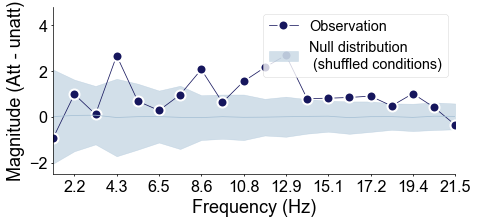

In [153]:
# Font size configuration for easy adjustment
scale = 0.9

XTICK_FONT_SIZE = 18 * scale
YTICK_FONT_SIZE = 18 * scale
XLABEL_FONT_SIZE = 20 * scale
YLABEL_FONT_SIZE = 20 * scale
LEGEND_FONT_SIZE = 16 * scale
TEXT_FONT_SIZE = 18 * scale
FIG_WIDTH = 4 * 1.7
FIG_HEIGHT = 2.05 * 1.6

config = {
    'XTICK_FONT_SIZE': XTICK_FONT_SIZE,
    'YTICK_FONT_SIZE': YTICK_FONT_SIZE,
    'XLABEL_FONT_SIZE': XLABEL_FONT_SIZE,
    'YLABEL_FONT_SIZE': YLABEL_FONT_SIZE,
    'LEGEND_FONT_SIZE': LEGEND_FONT_SIZE,
    'TEXT_FONT_SIZE': TEXT_FONT_SIZE,
    'FIG_WIDTH': FIG_WIDTH,
    'FIG_HEIGHT': FIG_HEIGHT
}

mc_diff_list = np.load('/projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/Result_DecodingNet/fft_stats/T1perm1000_shuffle_2cons.npy')
mc_diff_list = mc_diff_list[:,0,:]


pltSet.SetPlotParams()
pltSet.SetPlotDim(FIG_WIDTH, FIG_HEIGHT)

fig, ax = plt.subplots()
ax.spines[['right', 'top']].set_visible(False)
    

plt.plot(s_list[:21],color='#16165d',marker="o",markersize=10,markeredgecolor='white',markeredgewidth=2, label='Observation')
    

input_arr = np.array(mc_diff_list[:,:21])
y = np.mean(input_arr,axis=0)

x_tmp_arr = np.arange(0,21) 


plt.plot(y,color='#a6c0d5')

error = np.std(input_arr,axis=0)
plt.fill_between(x_tmp_arr, y-error, y+error,alpha=0.5,color='#a6c0d5',label='Null distribution \n (shuffled conditions)')


# plt.ylim(-2.5,5)


my_list = list(positive_freqs1[2:21:2])
formatted_list = [f"{x:.1f}" for x in my_list]
print(formatted_list)  # ['1.23', '2.35', '3.46']


plt.xlim(1,20)
plt.ylim(-2.5,4.8)
plt.xticks([2,4,6,8,10,12,14,16,18,20], formatted_list, fontsize=XTICK_FONT_SIZE)
plt.yticks(fontsize=YTICK_FONT_SIZE)
plt.ylabel('Magnitude (Att - unatt)', fontsize=YLABEL_FONT_SIZE)
plt.xlabel('Frequency (Hz)', fontsize=XLABEL_FONT_SIZE)
plt.legend(fontsize=LEGEND_FONT_SIZE)

plt.savefig('/projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/Result_DecodingNet/Manuscript_Figures/'
                 'T1coupling_fft_stats_0818.svg', dpi=300)
plt.show()

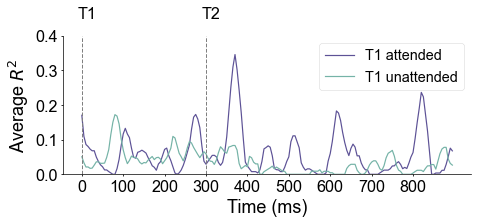

In [154]:
plot_T1_coupling(coupling_data1,coupling_data2, config=config)

In [85]:
from scipy.signal import find_peaks

4
[ 4 12 11  8  7 10  1  6  2 14 18 13 15  5 16 19 22  9  3 17 27 21 20 25
 23 29 56 24 30 66 54 41 52 33 49 32 91 51 62 34 90 92 31 57 89 61 47 55
 48 45 36 39 46 84 58 40 50 26 42 83 59 38 64 35 67 53 37 43 28 71 60 72
 77 86 79 69 76 78 80 75 74 65 63 73 88 82 68 85 87 81 44 70  0]
4.301075268817204
[ 3  7 11 13 17 21 24 26 28 32 35 38 40 44 46 48]
1
[ 1  7  6  3 14 20 10  2 21 19 13 26  4  5  8 11 15 17 18  9 27 25 22 23
 24 16 29 51 55 49 33 30 59 12 92 28 56 57 61 50 89 65 43 31 90 42 67 47
 64 44 70 60 35 87 66 86 88 58 91 32 48 54 52 84 80 83 39 82 81 69 36 71
 34 63 40 76 72 45 78 79 85 77 68 74 41 38 75 73 62 53 37 46  0]


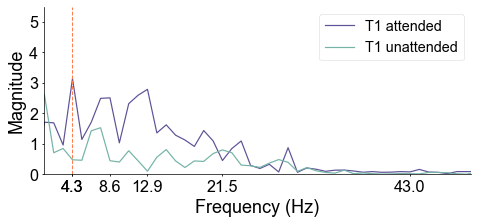

In [156]:
pltSet.SetPlotDim(FIG_WIDTH, FIG_HEIGHT)

fig, ax = plt.subplots()


plot_one_fft(coupling_data1,label_str='T1 attended',is_mark=True,ax=ax)

plot_one_fft(coupling_data2,label_str='T1 unattended',is_mark=False,ax=ax)

T2_diff_coupling = coupling_data1-coupling_data2

plt.xlabel("Frequency (Hz)", fontsize=XLABEL_FONT_SIZE)
plt.ylabel("Magnitude", fontsize=YLABEL_FONT_SIZE)
plt.yticks(fontsize=YTICK_FONT_SIZE)
plt.legend(fontsize=LEGEND_FONT_SIZE)

ax.tick_params(axis='x', labelsize=XTICK_FONT_SIZE)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}"))

plt.xlim(1,50)
plt.ylim(0,5.5)
plot_str = 'T1fft_%s_%s_0-150_0325' % (lobe1_str,lobe2_str)

plt.savefig('/projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/Result_DecodingNet/Manuscript_Figures/'
            '%s_win%s_0818.svg' % (plot_str,str(win)), dpi=300)

### T2 results

In [157]:
lobe1_str='occipital'
lobe2_str='EC&PHC'
win=np.array([9,39])

memory = np.concatenate((get_lobe_idxs(['parahippocampal','entorhinal'],hemi='lh'),get_lobe_idxs(['parahippocampal','entorhinal'],hemi='rh')))

mc_size=1000
window=False

arr1 = T2at_arr.copy()
arr2 = T2uat_arr.copy()
print(np.shape(arr1))

new_y1, new_y2 = arr1.transpose(1, 2, 0),arr2.transpose(1, 2, 0)
y1,y2=new_y1, new_y2
print(np.shape(y1))

n = np.shape(y1)[0]  # number of sessions
bin_arr = get_balanced_bin_arr(n)

random_idxs = random.sample(range(0, 2 ** n), mc_size)

if not window:
    window = [0, np.shape(y1)[1]]

i=0

positive_freqs1, positive_magnitudes1, positive_freqs2, positive_magnitudes2,coupling_data1,coupling_data2 = get_target_fft_data(y1.transpose(2,0,1),y2.transpose(2,0,1), 
                                                                                              memory,occipital_idxs,lobe1_str,lobe2_str,win_T2=60)

coupling_data21=coupling_data1
is_two_side=False
if is_two_side:
    s_list = np.abs(positive_magnitudes1 - positive_magnitudes2)
else:
    s_list = positive_magnitudes1 - positive_magnitudes2

parahippocampal
entorhinal
[38, 34]
parahippocampal
entorhinal
[39, 35]
(68, 20, 259)
(20, 259, 68)


In [158]:
positive_freqs1, positive_magnitudes1, positive_freqs2, positive_magnitudes2 = get_target_fft(y1.transpose(2,0,1),y2.transpose(2,0,1), 
                                                                                              memory,occipital_idxs,lobe1_str,lobe2_str,win_T2=60,roundfreq=False)


['2.1', '4.2', '6.3', '8.5', '10.6', '12.7', '14.8', '16.9', '19.0', '21.2']


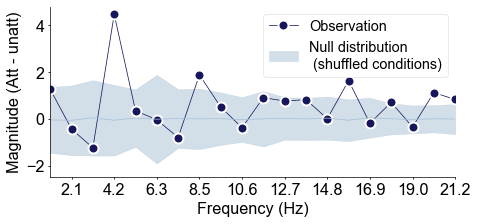

In [159]:
mc_diff_list = np.load('/projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/Result_DecodingNet/fft_stats/T2perm1000_shuffle_2cons.npy')
mc_diff_list = mc_diff_list[:,0,:]

pltSet.SetPlotParams()
pltSet.SetPlotDim(FIG_WIDTH, FIG_HEIGHT)

fig, ax = plt.subplots()
ax.spines[['right', 'top']].set_visible(False)
plt.plot(s_list[:21],color='#16165d',marker="o",markersize=10,markeredgecolor='white',markeredgewidth=2, label='Observation')
    

input_arr = np.array(mc_diff_list[:,:21])
y = np.mean(input_arr,axis=0)

x_tmp_arr = np.arange(0,21) 


plt.plot(y,color='#a6c0d5')

error = np.std(input_arr,axis=0)
plt.fill_between(x_tmp_arr, y-error, y+error,alpha=0.5,color='#a6c0d5',label='Null distribution \n (shuffled conditions)')


# plt.ylim(-2.5,5)
my_list = list(positive_freqs1[2:21:2])
formatted_list = [f"{x:.1f}" for x in my_list]
print(formatted_list)  # ['1.23', '2.35', '3.46']


plt.xlim(1,20)
plt.ylim(-2.5,4.8)
plt.yticks(fontsize=YTICK_FONT_SIZE)
plt.xticks([2,4,6,8,10,12,14,16,18,20],formatted_list, fontsize=XTICK_FONT_SIZE)

plt.ylabel('Magnitude (Att - unatt)', fontsize=YTICK_FONT_SIZE)
plt.xlabel('Frequency (Hz)', fontsize=XTICK_FONT_SIZE)
plt.legend(fontsize=LEGEND_FONT_SIZE)
plt.savefig('/projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/Result_DecodingNet/Manuscript_Figures/'
                'T2coupling_fft_stats_0818.svg', dpi=300)
plt.show()



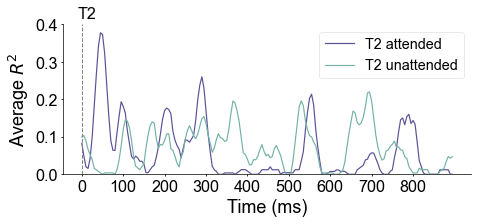

In [160]:
plot_T2_coupling(coupling_data1,coupling_data2,config=config)

4
[ 4  1 11  8  5 13  2 19 15  6  9 12 17 10  7 18 20 16 22 24 21 23 14 26
 25 27  3 29 31 30 33 46 53 58 49 61 28 32 54 41 59 65 89 48 40 56 66 42
 34 87 91 37 38 84 71 45 44 90 39 68 79 36 47 88 60 52 64 73 62 93 72 50
 70 76 35 75 83 77 85 43 80 81 74 78 67 82 92 63 57 51 55 69 86  0]
4.232804232804233
[ 3  7 10 12 14 16 18 21 23 25 28 30 32 36 40 45 48]
5
[ 5  2  1 11  7 10  6 18  3 13 16  8 21  9  4 19 23 29 12 17 24 22 14 26
 25 20 55 31 34 50 59 28 15 56 41 57 48 42 90 27 40 65 51 46 44 54 32 63
 92 87 33 49 37 38 86 36 45 85 64 35 43 80 39 52 72 60 91 78 67 89 83 61
 79 47 74 76 75 53 71 77 58 30 82 81 73 66 70 88 69 93 84 62 68  0]


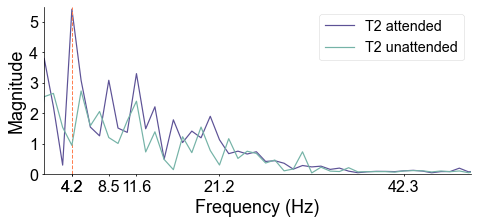

In [162]:
pltSet.SetPlotDim(FIG_WIDTH, FIG_HEIGHT)

fig, ax = plt.subplots()

plot_one_fft(coupling_data1,win=(9+60,-1),label_str='T2 attended',is_mark=True,ax=ax)

plot_one_fft(coupling_data2,win=(9+60,-1),label_str='T2 unattended',is_mark=False,ax=ax)

T2_diff_coupling = coupling_data1-coupling_data2

plt.xlabel("Frequency (Hz)", fontsize=XLABEL_FONT_SIZE )
plt.ylabel("Magnitude", fontsize=YLABEL_FONT_SIZE)
plt.legend(fontsize=LEGEND_FONT_SIZE)
plt.yticks(fontsize=YTICK_FONT_SIZE)
plt.legend(fontsize=LEGEND_FONT_SIZE)

ax.tick_params(axis='x', labelsize=XTICK_FONT_SIZE)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}"))

plt.xlim(1,50)
plt.ylim(0,5.5)
plot_str = 'T2fft_%s_%s_0-150_0325' % (lobe1_str,lobe2_str)

plt.savefig('/projectnb/rdenlab/Users/Jiating/TA2_work/MEG_output/Result_DecodingNet/Manuscript_Figures/'
            '%s_win%s_0818.svg' % (plot_str,str(win)), dpi=300)

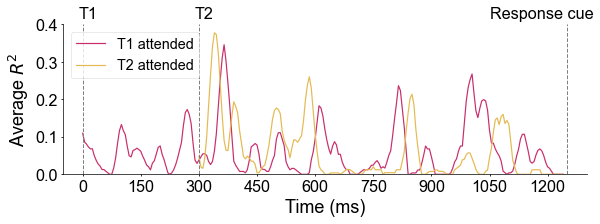

In [135]:
plot_T1T2coupling(coupling_data11,coupling_data21,config=config)